### RNN (Recurent Neural Network) : 단기 메모리
- 순서가 중요 / 이전 사건이 다음 사건에 영향을 미치는 구조
- 순서가 중요한 데이터 : 시계열
- 자연어, 주식, 날씨, 실시간 센서 데이터
- 단점 : 장기 메모리에 약함
- 개선 : LSTM (RNN에 비해 오래 기억하지만 그래도 희석됨) 
- 트랜스포머 : 집중해야 할 것 즉 기억해야 할 중요내용만 저장(어텐션), 마스킹
### MLP
- 모든 입력이 독립적, 자연어는 단어의 순서가 중요함
- RNN 기억

    $h_t$

    $t$

In [49]:
from nltk.corpus import movie_reviews
reviews = [movie_reviews.raw(fileid) for fileid in movie_reviews.fileids()]
categories = [movie_reviews.categories(fileid)[0] for fileid in movie_reviews.fileids()]

In [50]:
len(reviews), len(categories[0]), set(categories)

(2000, 3, {'neg', 'pos'})

In [51]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
np.random.seed(42)
tf.random.set_seed(42)

In [52]:
# 사용할 단어 수
max_words = 10000
tokenizer = Tokenizer(num_words=max_words, oov_token='UNK')
tokenizer.fit_on_texts(reviews) # 단어 인덱스 구축
x = tokenizer.texts_to_sequences(reviews)  # 인덱스를 기반으로 원래 문장을 숫자로 변환(벡터화, 개별적으로 즉 길이는 서로 다름)

In [53]:
len(x[0]), len(x[1]), x[0][:10]

(710, 240, [98, 77, 949, 4622, 131, 6, 3, 2016, 789, 3764])

In [54]:
# 학습을 위해서는 모든 문장의 길이가 같아야 함 -> 패딩 : 짧으면 채우고 길면 자르고
from tensorflow.keras.preprocessing.sequence import pad_sequences
maxlen = 500
x = pad_sequences(x, maxlen=maxlen, truncating='pre') # 앞을 자름


In [55]:
len(x[0]), len(x[1]), x[0][:10]

(500, 500, array([ 911,  115,   53,   21, 5278,    5, 1387,  172,    9,  633]))

In [56]:
label_dict = {'pos':1, 'neg':0}
y = np.array([label_dict[c] for c in categories])
y[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [57]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42, test_size=0.2)

In [58]:
x_train.shape

(1600, 500)

In [59]:
# 일반 신경망으로 분리
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Embedding, Dropout

model = Sequential([
    Embedding(max_words, 32, input_length=maxlen),     # 1600, 500 -> 1600, 500, 32
    Dropout(0.5),
    Flatten(),
    Dense(1, activation='sigmoid') # 확률분포
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])
history = model.fit(x_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - acc: 0.5047 - loss: 0.6937 - val_acc: 0.4938 - val_loss: 0.6952
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.8836 - loss: 0.6213 - val_acc: 0.5375 - val_loss: 0.6925
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.9578 - loss: 0.5345 - val_acc: 0.5625 - val_loss: 0.6874
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.9812 - loss: 0.4192 - val_acc: 0.5656 - val_loss: 0.6791
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.9945 - loss: 0.2925 - val_acc: 0.5844 - val_loss: 0.6646
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.9984 - loss: 0.1922 - val_acc: 0.5938 - val_loss: 0.6528
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.9977 - loss: 0.1250 - val_acc: 0.6125 - val_loss: 0.6444
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 1.0000 - loss: 0.0843 - val_acc: 0.6094 - val_loss: 0.6373
Epoch 9/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 1.0000 - loss:

In [60]:
temp = Embedding(max_words, 32, input_length=maxlen)(x_train)
temp.shape, Flatten()(temp).shape

(TensorShape([1600, 500, 32]), TensorShape([1600, 16000]))

dict_keys(['acc', 'loss', 'val_acc', 'val_loss'])


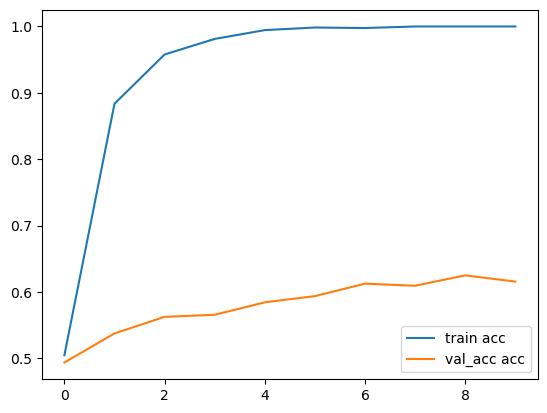

In [61]:
# 시각화
import matplotlib.pyplot as plt
print(history.history.keys())
plt.plot(history.history['acc'], label = 'train acc')
plt.plot(history.history['val_acc'], label = 'val_acc acc')
plt.legend()
plt.show()

In [62]:
y_pred = model.evaluate(x_test, y_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.6625 - loss: 0.6144 


In [63]:
from tensorflow.keras.layers import SimpleRNN
model = Sequential([
    Embedding(max_words, 32, input_length=maxlen),     # 1600, 500 -> 1600, 500, 32
    SimpleRNN(32),     # 1600, 32 단순선형모델에 사용되는 Flatten 대신
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid') # 확률분포
])

In [64]:
temp = Embedding(max_words, 32, input_length=maxlen)(x_train)
SimpleRNN(32)(temp).shape

TensorShape([1600, 32])

In [65]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])
history = model.fit(x_train, y_train, epochs=10, validation_split=0.2)
y_pred = model.evaluate(x_test, y_test)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - acc: 0.4953 - loss: 0.7064 - val_acc: 0.4875 - val_loss: 0.6973
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - acc: 0.5430 - loss: 0.6900 - val_acc: 0.4938 - val_loss: 0.6978
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - acc: 0.5555 - loss: 0.6855 - val_acc: 0.4812 - val_loss: 0.6978
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - acc: 0.6336 - loss: 0.6507 - val_acc: 0.4938 - val_loss: 0.7021
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - acc: 0.6922 - loss: 0.6144 - val_acc: 0.6094 - val_loss: 0.6439
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - acc: 0.8039 - loss: 0.5114 - val_acc: 0.7063 - val_loss: 0.5786
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - acc: 0.9203 - loss: 0.2875 - val_acc: 0.7219 - val_loss: 0.6005
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - acc: 0.9547 - loss: 0.1753 - val_acc: 0.7281 - val_loss: 0.6854
Epoch 9/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - acc: 0.9797